# PSE Pulse User Acceptance Testing (UAT) Analysis

**Chapter IV support notebook**  
**Respondents:** 8 budding traders  
**Analysis date:** October 1, 2026

This notebook summarizes the completed UAT responses for **PSE Pulse** and aligns the findings with the stakeholder-facing functional and non-functional requirements defined in Chapter III.

The analysis is **descriptive**, not inferential. The same eight purposively selected budding traders who participated in requirements elicitation also participated in UAT; therefore, the findings support acceptance **within the intended stakeholder group** and are not generalized to all Filipino investors or traders.

## 1. Data handling and privacy

The source workbook contained timestamps and email addresses. These identifiers are **not reproduced in this notebook**. Respondents are anonymized as **P01–P08**, and only the fields needed for UAT analysis are retained.

All eight respondents provided consent and confirmed that they understood PSE Pulse as an educational/analytical tool rather than a source of financial advice or direct trading recommendations.

In [59]:
from collections import Counter, defaultdict
from statistics import mean, median
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# Pastel visual theme requested for the UAT report.
PASTEL = [
    '#A8DADC', '#F7CAD0', '#CDEAC0', '#FFD6A5',
    '#BDE0FE', '#E2CFEA', '#FFF1A8', '#C9E4DE',
    '#F6BDC0', '#C6DEF1'
]
ACCENT = '#7B6D8D'
GRID = '#D9D9D9'

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

def md_table(headers, rows):
    def esc(x):
        return str(x).replace('|', '/').replace(chr(10), ' ')
    lines = ['| ' + ' | '.join(map(esc, headers)) + ' |',
             '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines += ['| ' + ' | '.join(esc(v) for v in row) + ' |' for row in rows]
    display(Markdown(chr(10).join(lines)))

def add_bar_labels(ax, values, suffix='', fmt='{:.1f}'):
    for patch, value in zip(ax.patches, values):
        width = patch.get_width()
        ax.text(width + 0.8, patch.get_y() + patch.get_height()/2,
                fmt.format(value) + suffix, va='center', fontsize=9)

# With 8 participants, the Chapter III 80% stakeholder threshold requires 7/8 responses.
N = 8
PASS_COUNT = 7
PASS_PCT = 100 * PASS_COUNT / N  # 87.5%

In [60]:
records = [{'participant': 'P01', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Desktop Computer', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Very Clear', 'identify_best_method': 'Very Easy', 'principal_vs_naive': 'Very Easy', 'historical_help': 'Very Helpful', 'forecast_help': 'Very Helpful', 'ranking_help': 'Moderately Helpful', 'watchlist_help': 'Very Helpful', 'learn_stocks_help': 'Very Helpful', 'disclaimer_help': 'Moderately Helpful', 'view_modes_help': 'Very Helpful', 'ask_ai_help': 'Very Helpful', 'clean_organized': 'Agree', 'loads_quickly': 'Agree', 'would_use': 'Agree', 'would_recommend': 'Agree', 'source_freshness': 'Agree', 'controls_work': 'Agree', 'responsive_readability': 'Agree', 'visual_comfort': 'Agree', 'most_useful': 'The top and losoer forecasted gainer, immediate info or summary of the whole list.', 'issues': None, 'recommendations': 'None, the dashboard is already beginner friendly and provides enough info for further knowledge to the subject. '}, {'participant': 'P02', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Tablet', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Somewhat Clear', 'identify_best_method': 'Somewhat Easy', 'principal_vs_naive': 'Neutral', 'historical_help': 'Extremely Helpful', 'forecast_help': 'Extremely Helpful', 'ranking_help': 'Very Helpful', 'watchlist_help': 'Extremely Helpful', 'learn_stocks_help': 'Extremely Helpful', 'disclaimer_help': 'Extremely Helpful', 'view_modes_help': 'Extremely Helpful', 'ask_ai_help': 'Very Helpful', 'clean_organized': 'Strongly Agree', 'loads_quickly': 'Strongly Agree', 'would_use': 'Agree', 'would_recommend': 'Strongly Agree', 'source_freshness': 'Strongly Agree', 'controls_work': 'Strongly Agree', 'responsive_readability': 'Strongly Agree', 'visual_comfort': 'Agree', 'most_useful': 'The beginner and advanced mode toggle on the company stock pages, paired with the Ask AI Assistant, was definitely the most helpful', 'issues': None, 'recommendations': 'Add small question-mark icons or tooltips next to technical acronyms'}, {'participant': 'P03', 'responsible_use_understood': 'Yes', 'experience': 'Intermediate', 'device': 'Desktop Computer', 'company_selection': 'Somewhat Easy', 'historical_understanding': 'Somewhat Easy', 'actual_vs_predicted_clarity': 'Somewhat Clear', 'performance_difference_clarity': 'Somewhat Clear', 'identify_best_method': 'Somewhat Easy', 'principal_vs_naive': 'Somewhat Easy', 'historical_help': 'Extremely Helpful', 'forecast_help': 'Extremely Helpful', 'ranking_help': 'Extremely Helpful', 'watchlist_help': 'Extremely Helpful', 'learn_stocks_help': 'Extremely Helpful', 'disclaimer_help': 'Extremely Helpful', 'view_modes_help': 'Extremely Helpful', 'ask_ai_help': 'Extremely Helpful', 'clean_organized': 'Strongly Agree', 'loads_quickly': 'Strongly Agree', 'would_use': 'Strongly Agree', 'would_recommend': 'Strongly Agree', 'source_freshness': 'Strongly Agree', 'controls_work': 'Strongly Agree', 'responsive_readability': 'Strongly Agree', 'visual_comfort': 'Strongly Agree', 'most_useful': 'Ask AI Assistant. I could just type what I didn’t get about the chart or the forecast instead of guessing what the numbers meant. It made the site feel more like a tutor than a random dashboard.', 'issues': None, 'recommendations': 'Add a short first-time walkthrough and tiny tooltips on terms like forecast, model ranking, and volume. A simple up/down color legend on the charts would also help people who are still new to PSE stocks.'}, {'participant': 'P04', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Laptop', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Very Clear', 'identify_best_method': 'Somewhat Easy', 'principal_vs_naive': 'Somewhat Easy', 'historical_help': 'Extremely Helpful', 'forecast_help': 'Extremely Helpful', 'ranking_help': 'Extremely Helpful', 'watchlist_help': 'Extremely Helpful', 'learn_stocks_help': 'Extremely Helpful', 'disclaimer_help': 'Extremely Helpful', 'view_modes_help': 'Extremely Helpful', 'ask_ai_help': 'Extremely Helpful', 'clean_organized': 'Strongly Agree', 'loads_quickly': 'Strongly Agree', 'would_use': 'Strongly Agree', 'would_recommend': 'Strongly Agree', 'source_freshness': 'Strongly Agree', 'controls_work': 'Strongly Agree', 'responsive_readability': 'Agree', 'visual_comfort': 'Agree', 'most_useful': 'AI Assistant, summary of losers and gainers, next day forecast', 'issues': None, 'recommendations': 'Some improvements to light mode'}, {'participant': 'P05', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Mobile Phone', 'company_selection': 'Somewhat Difficult', 'historical_understanding': 'Neutral', 'actual_vs_predicted_clarity': 'Neutral', 'performance_difference_clarity': 'Neutral', 'identify_best_method': 'Somewhat Difficult', 'principal_vs_naive': 'Neutral', 'historical_help': 'Moderately Helpful', 'forecast_help': 'Very Helpful', 'ranking_help': 'Moderately Helpful', 'watchlist_help': 'Moderately Helpful', 'learn_stocks_help': 'Moderately Helpful', 'disclaimer_help': 'Slightly Helpful', 'view_modes_help': 'Moderately Helpful', 'ask_ai_help': 'Very Helpful', 'clean_organized': 'Neutral', 'loads_quickly': 'Neutral', 'would_use': 'Agree', 'would_recommend': 'Agree', 'source_freshness': 'Agree', 'controls_work': 'Agree', 'responsive_readability': 'Neutral', 'visual_comfort': 'Agree', 'most_useful': 'Using the chart, as a beginner it helps you to understand the flow of investment.', 'issues': None, 'recommendations': "I recommend the use of simple jargon words when talking about the process of investment, for a beginner it's difficult to follow. "}, {'participant': 'P06', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Mobile Phone', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Very Clear', 'identify_best_method': 'Very Easy', 'principal_vs_naive': 'Very Easy', 'historical_help': 'Moderately Helpful', 'forecast_help': 'Moderately Helpful', 'ranking_help': 'Moderately Helpful', 'watchlist_help': 'Moderately Helpful', 'learn_stocks_help': 'Moderately Helpful', 'disclaimer_help': 'Moderately Helpful', 'view_modes_help': 'Moderately Helpful', 'ask_ai_help': 'Moderately Helpful', 'clean_organized': 'Neutral', 'loads_quickly': 'Neutral', 'would_use': 'Neutral', 'would_recommend': 'Neutral', 'source_freshness': 'Neutral', 'controls_work': 'Neutral', 'responsive_readability': 'Neutral', 'visual_comfort': 'Neutral', 'most_useful': 'About the forecasting. It helps me a lot to think what will be my next plan.', 'issues': 'None so far.', 'recommendations': 'I think these all best for me and all of them are designs for learning process.'}, {'participant': 'P07', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Mobile Phone', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Very Clear', 'identify_best_method': 'Very Easy', 'principal_vs_naive': 'Very Easy', 'historical_help': 'Extremely Helpful', 'forecast_help': 'Extremely Helpful', 'ranking_help': 'Extremely Helpful', 'watchlist_help': 'Very Helpful', 'learn_stocks_help': 'Extremely Helpful', 'disclaimer_help': 'Extremely Helpful', 'view_modes_help': 'Extremely Helpful', 'ask_ai_help': 'Very Helpful', 'clean_organized': 'Strongly Agree', 'loads_quickly': 'Strongly Agree', 'would_use': 'Strongly Agree', 'would_recommend': 'Strongly Agree', 'source_freshness': 'Strongly Agree', 'controls_work': 'Strongly Agree', 'responsive_readability': 'Strongly Agree', 'visual_comfort': 'Strongly Agree', 'most_useful': 'The AI assistant really helps me with my learning', 'issues': None, 'recommendations': 'I believe that everything already fine, including AI assistants that can provide support.'}, {'participant': 'P08', 'responsible_use_understood': 'Yes', 'experience': 'Beginner', 'device': 'Mobile Phone', 'company_selection': 'Very Easy', 'historical_understanding': 'Very Easy', 'actual_vs_predicted_clarity': 'Very Clear', 'performance_difference_clarity': 'Very Clear', 'identify_best_method': 'Very Easy', 'principal_vs_naive': 'Very Easy', 'historical_help': 'Extremely Helpful', 'forecast_help': 'Extremely Helpful', 'ranking_help': 'Extremely Helpful', 'watchlist_help': 'Extremely Helpful', 'learn_stocks_help': 'Very Helpful', 'disclaimer_help': 'Extremely Helpful', 'view_modes_help': 'Very Helpful', 'ask_ai_help': 'Very Helpful', 'clean_organized': 'Strongly Agree', 'loads_quickly': 'Strongly Agree', 'would_use': 'Strongly Agree', 'would_recommend': 'Agree', 'source_freshness': 'Strongly Agree', 'controls_work': 'Strongly Agree', 'responsive_readability': 'Strongly Agree', 'visual_comfort': 'Strongly Agree', 'most_useful': 'Historical data tables on the Data Overview page utilize sticky column headers and support smooth horizontal scrolling.', 'issues': None, 'recommendations': 'Step-by-step guided tour when a user first opens the dashboard.'}]

## 2. Scoring rules

The questionnaire used several 5-point response formats. For consistent descriptive analysis, the ordinal responses are mapped to scores from **1 to 5**.

A **positive response** is defined as a score of **4 or 5**, consistent with the Chapter III usability criteria. With eight participants, an 80% threshold requires at least **7 of 8 participants**, equivalent to **87.5%**.

- Ease: 1 = Very Difficult, 5 = Very Easy
- Clarity: 1 = Very Unclear, 5 = Very Clear
- Helpfulness: 1 = Not Helpful, 5 = Extremely Helpful
- Agreement: 1 = Strongly Disagree, 5 = Strongly Agree

The notebook reports counts, percentages, means, and medians. Means are used only as descriptive summaries of the ordered response scale.

In [61]:
EASE = {'Very Difficult':1, 'Somewhat Difficult':2, 'Neutral':3, 'Somewhat Easy':4, 'Very Easy':5}
CLARITY = {'Very Unclear':1, 'Somewhat Unclear':2, 'Neutral':3, 'Somewhat Clear':4, 'Very Clear':5}
HELP = {'Not Helpful':1, 'Slightly Helpful':2, 'Moderately Helpful':3, 'Very Helpful':4, 'Extremely Helpful':5}
AGREE = {'Strongly Disagree':1, 'Disagree':2, 'Neutral':3, 'Agree':4, 'Strongly Agree':5}

def summarize(key, mapping):
    vals = [mapping[r[key]] for r in records if r.get(key) in mapping]
    return {
        'n': len(vals),
        'mean': mean(vals),
        'median': median(vals),
        'positive_n': sum(v >= 4 for v in vals),
        'positive_pct': 100 * sum(v >= 4 for v in vals) / len(vals),
        'neutral_n': sum(v == 3 for v in vals),
        'negative_n': sum(v <= 2 for v in vals),
    }

## 3. Participant profile

In [62]:
experience_counts = Counter(r['experience'] for r in records)
device_counts = Counter(r['device'] for r in records)

md_table(
    ['Experience level', 'Count', 'Percent'],
    [[k, v, f'{100*v/N:.1f}%'] for k, v in experience_counts.most_common()]
)

| Experience level | Count | Percent |
| --- | --- | --- |
| Beginner | 7 | 87.5% |
| Intermediate | 1 | 12.5% |

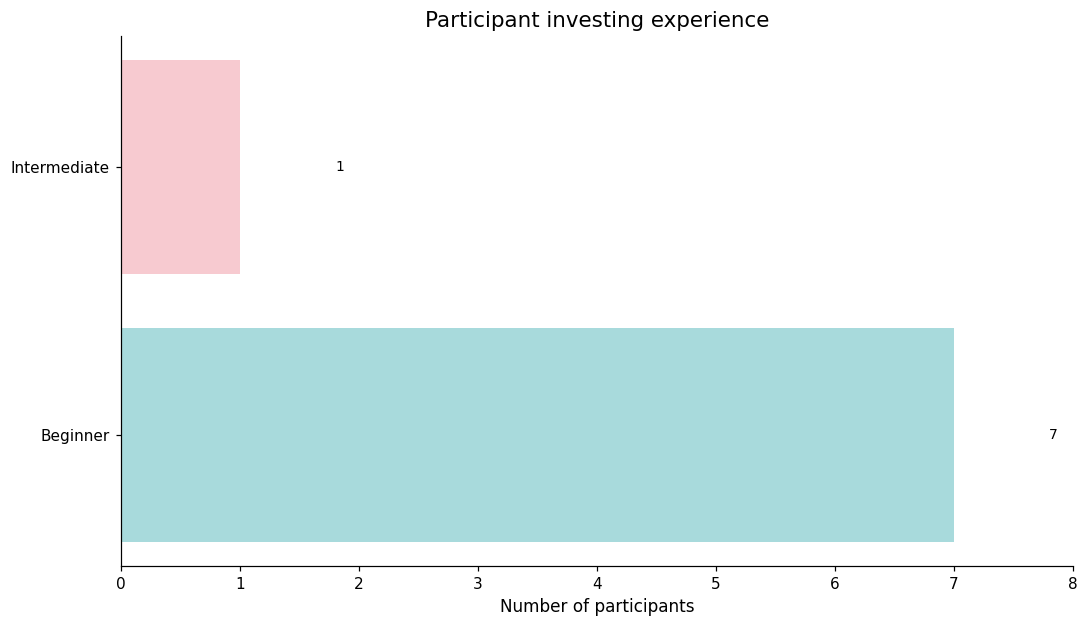

In [63]:
labels = list(experience_counts.keys())
vals = [experience_counts[x] for x in labels]
fig, ax = plt.subplots()
ax.barh(labels, vals, color=PASTEL[:len(labels)])
ax.set_title('Participant investing experience')
ax.set_xlabel('Number of participants')
ax.set_xlim(0, max(vals)+1)
add_bar_labels(ax, vals, fmt='{:.0f}')
plt.tight_layout()
plt.show()

In [64]:
md_table(
    ['Primary device', 'Count', 'Percent'],
    [[k, v, f'{100*v/N:.1f}%'] for k, v in device_counts.most_common()]
)

| Primary device | Count | Percent |
| --- | --- | --- |
| Mobile Phone | 4 | 50.0% |
| Desktop Computer | 2 | 25.0% |
| Tablet | 1 | 12.5% |
| Laptop | 1 | 12.5% |

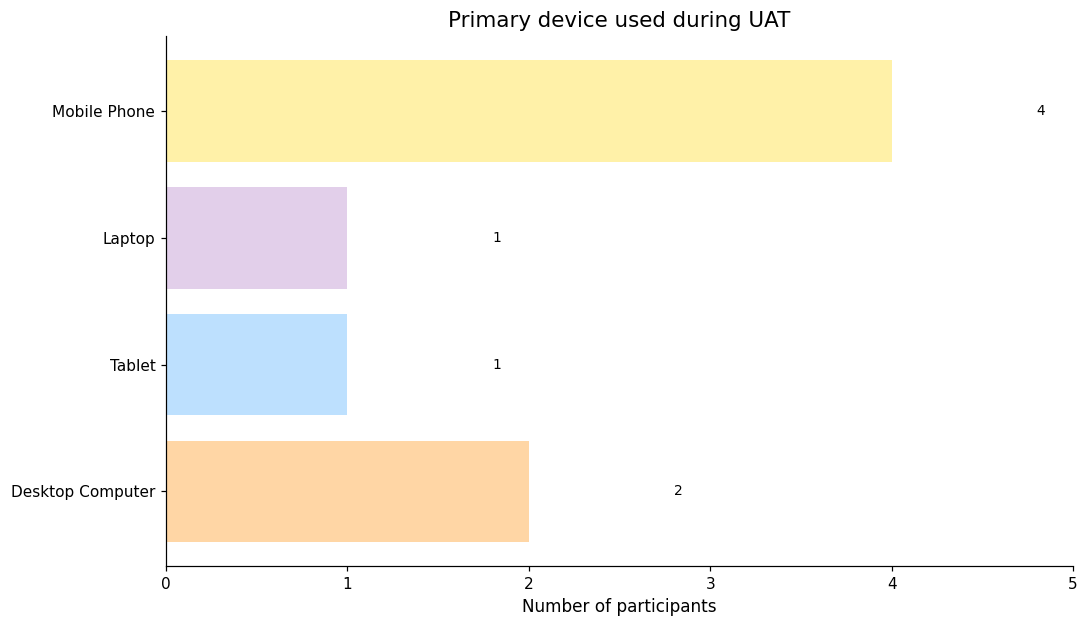

In [65]:
labels = list(device_counts.keys())
vals = [device_counts[x] for x in labels]
fig, ax = plt.subplots()
ax.barh(labels, vals, color=PASTEL[3:3+len(labels)])
ax.set_title('Primary device used during UAT')
ax.set_xlabel('Number of participants')
ax.set_xlim(0, max(vals)+1)
add_bar_labels(ax, vals, fmt='{:.0f}')
plt.tight_layout()
plt.show()

In [66]:
display(Markdown(
    f"**Profile summary.** {experience_counts.get('Beginner',0)} of {N} participants "
    f"({100*experience_counts.get('Beginner',0)/N:.1f}%) identified as beginners. "
    f"Mobile phones were the most common device ({device_counts.get('Mobile Phone',0)}/{N}, "
    f"{100*device_counts.get('Mobile Phone',0)/N:.1f}%), which makes mobile usability particularly relevant to the UAT interpretation."
))

**Profile summary.** 7 of 8 participants (87.5%) identified as beginners. Mobile phones were the most common device (4/8, 50.0%), which makes mobile usability particularly relevant to the UAT interpretation.

## 4. Core usability, clarity, and model-comparison tasks

These items directly examine whether participants could navigate to a company, understand historical information and forecast charts, and interpret comparative model-performance evidence.

In [67]:
core_items = [
    ('Company selection / navigation', 'company_selection', EASE),
    ('Historical price & volume understanding', 'historical_understanding', EASE),
    ('Actual vs predicted chart clarity', 'actual_vs_predicted_clarity', CLARITY),
    ('Cross-company / model performance clarity', 'performance_difference_clarity', CLARITY),
    ('Identify best forecasting method', 'identify_best_method', EASE),
    ('Best principal model vs Naive', 'principal_vs_naive', EASE),
]
core_summary = []
for label, key, mapping in core_items:
    s = summarize(key, mapping)
    status = 'Meets 7/8 threshold' if s['positive_n'] >= PASS_COUNT else 'Below 7/8 threshold'
    core_summary.append((label, s, status))

md_table(
    ['UAT item', 'Mean / 5', 'Median', 'Positive (4–5)', 'Positive %', 'Threshold status'],
    [[label, f"{s['mean']:.2f}", f"{s['median']:.1f}", f"{s['positive_n']}/{N}",
      f"{s['positive_pct']:.1f}%", status]
     for label, s, status in core_summary]
)

| UAT item | Mean / 5 | Median | Positive (4–5) | Positive % | Threshold status |
| --- | --- | --- | --- | --- | --- |
| Company selection / navigation | 4.50 | 5.0 | 7/8 | 87.5% | Meets 7/8 threshold |
| Historical price & volume understanding | 4.62 | 5.0 | 7/8 | 87.5% | Meets 7/8 threshold |
| Actual vs predicted chart clarity | 4.62 | 5.0 | 7/8 | 87.5% | Meets 7/8 threshold |
| Cross-company / model performance clarity | 4.50 | 5.0 | 7/8 | 87.5% | Meets 7/8 threshold |
| Identify best forecasting method | 4.25 | 4.5 | 7/8 | 87.5% | Meets 7/8 threshold |
| Best principal model vs Naive | 4.25 | 4.5 | 6/8 | 75.0% | Below 7/8 threshold |

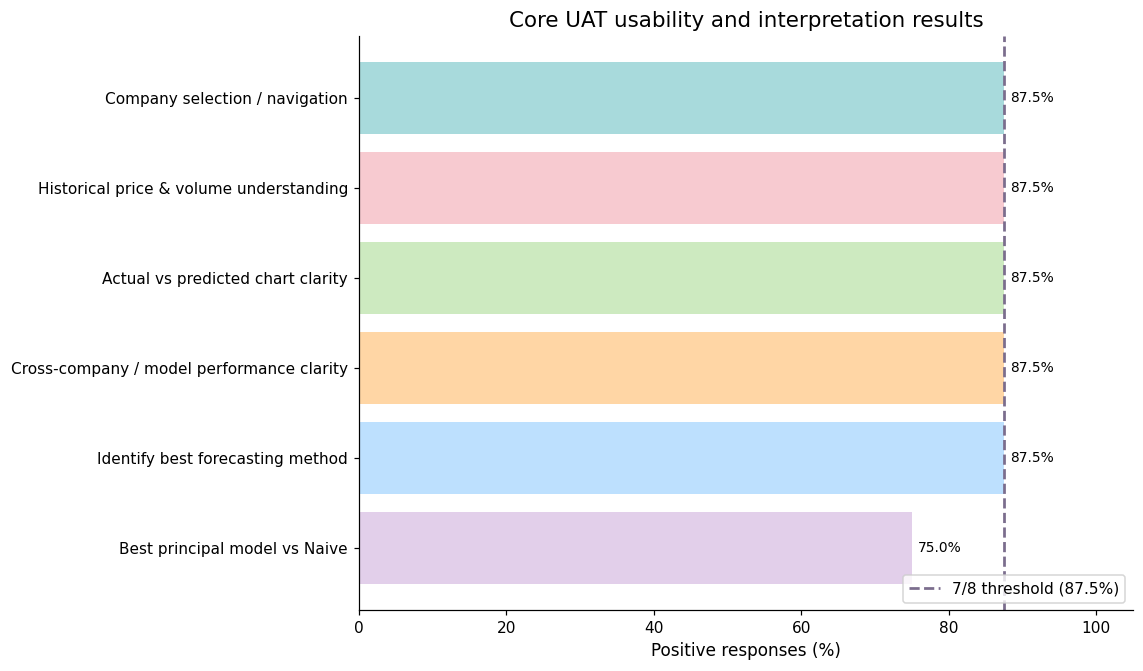

In [68]:
labels = [x[0] for x in core_summary]
vals = [x[1]['positive_pct'] for x in core_summary]
fig, ax = plt.subplots(figsize=(10.5, 6.2))
y = np.arange(len(labels))
ax.barh(y, vals, color=PASTEL[:len(labels)])
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.axvline(PASS_PCT, color=ACCENT, linestyle='--', linewidth=1.8, label=f'7/8 threshold ({PASS_PCT:.1f}%)')
ax.set_xlim(0, 105)
ax.set_xlabel('Positive responses (%)')
ax.set_title('Core UAT usability and interpretation results')
ax.legend(loc='lower right')
add_bar_labels(ax, vals, suffix='%')
plt.tight_layout()
plt.show()

In [69]:
passed = [label for label, s, _ in core_summary if s['positive_n'] >= PASS_COUNT]
below = [label for label, s, _ in core_summary if s['positive_n'] < PASS_COUNT]
display(Markdown(
    "**Interpretation.** Five of the six core perception items reached the 7-of-8 positive-response threshold. "
    "The strongest recurring usability pattern was that participants generally found company selection, historical information, "
    "actual-versus-predicted charts, and general model comparison understandable. "
    "The only core item below the threshold was **Best principal model vs Naive**, at 6/8 positive responses (75.0%). "
    "This identifies benchmark interpretation as the clearest remaining explanation/labeling opportunity."
))

**Interpretation.** Five of the six core perception items reached the 7-of-8 positive-response threshold. The strongest recurring usability pattern was that participants generally found company selection, historical information, actual-versus-predicted charts, and general model comparison understandable. The only core item below the threshold was **Best principal model vs Naive**, at 6/8 positive responses (75.0%). This identifies benchmark interpretation as the clearest remaining explanation/labeling opportunity.

## 5. Helpfulness of implemented PSE Pulse features

In [70]:
feature_items = [
    ('Historical Data Overview', 'historical_help'),
    ('Next-Day Price Forecasts', 'forecast_help'),
    ('Model Ranking Summaries', 'ranking_help'),
    ('My Watchlist', 'watchlist_help'),
    ('Learn Stocks', 'learn_stocks_help'),
    ('Responsible-Use Disclaimers', 'disclaimer_help'),
    ('Beginner / Advanced Modes', 'view_modes_help'),
    ('Ask AI Assistant', 'ask_ai_help'),
]
feature_summary=[]
for label,key in feature_items:
    s=summarize(key, HELP)
    feature_summary.append((label,s))

md_table(
    ['Feature', 'Mean helpfulness / 5', 'Median', 'Very/Extremely Helpful', 'Positive %'],
    [[label, f"{s['mean']:.2f}", f"{s['median']:.1f}", f"{s['positive_n']}/{N}", f"{s['positive_pct']:.1f}%"]
     for label,s in feature_summary]
)

| Feature | Mean helpfulness / 5 | Median | Very/Extremely Helpful | Positive % |
| --- | --- | --- | --- | --- |
| Historical Data Overview | 4.38 | 5.0 | 6/8 | 75.0% |
| Next-Day Price Forecasts | 4.50 | 5.0 | 7/8 | 87.5% |
| Model Ranking Summaries | 4.12 | 4.5 | 5/8 | 62.5% |
| My Watchlist | 4.25 | 4.5 | 6/8 | 75.0% |
| Learn Stocks | 4.25 | 4.5 | 6/8 | 75.0% |
| Responsible-Use Disclaimers | 4.12 | 5.0 | 5/8 | 62.5% |
| Beginner / Advanced Modes | 4.25 | 4.5 | 6/8 | 75.0% |
| Ask AI Assistant | 4.12 | 4.0 | 7/8 | 87.5% |

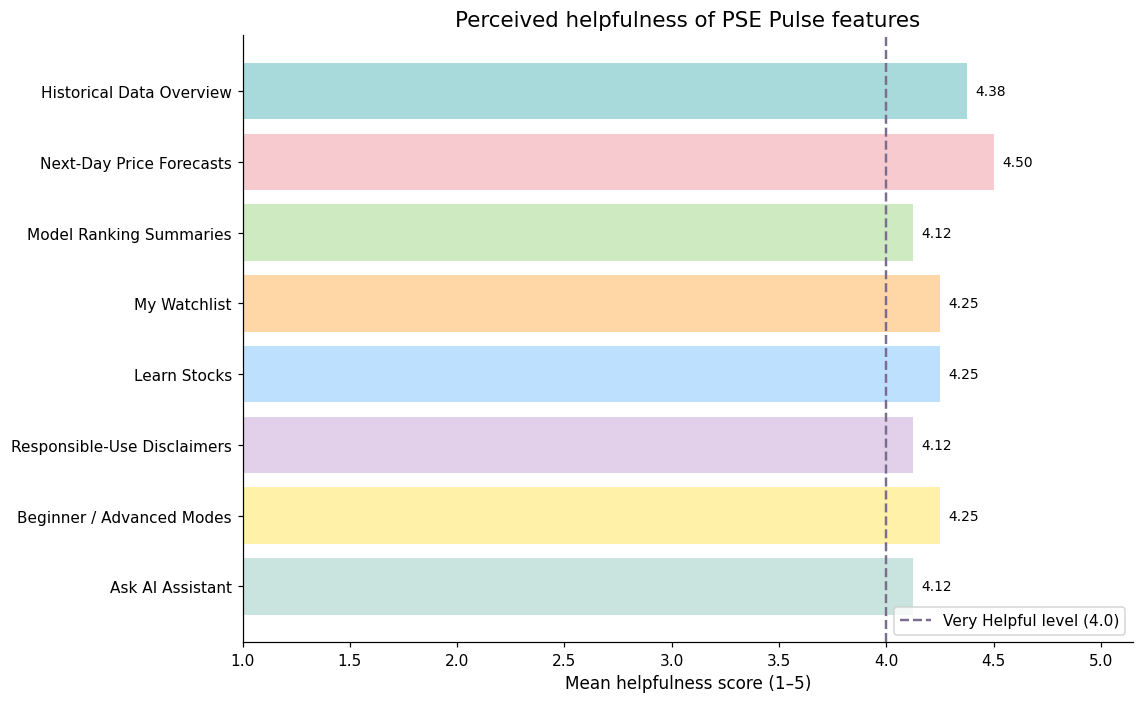

In [71]:
labels = [x[0] for x in feature_summary]
vals = [x[1]['mean'] for x in feature_summary]
fig, ax = plt.subplots(figsize=(10.5, 6.5))
y=np.arange(len(labels))
ax.barh(y, vals, color=PASTEL[:len(labels)])
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.set_xlim(1,5.15)
ax.axvline(4, color=ACCENT, linestyle='--', linewidth=1.6, label='Very Helpful level (4.0)')
ax.set_xlabel('Mean helpfulness score (1–5)')
ax.set_title('Perceived helpfulness of PSE Pulse features')
ax.legend(loc='lower right')
for patch, value in zip(ax.patches, vals):
    ax.text(value+0.04, patch.get_y()+patch.get_height()/2, f'{value:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

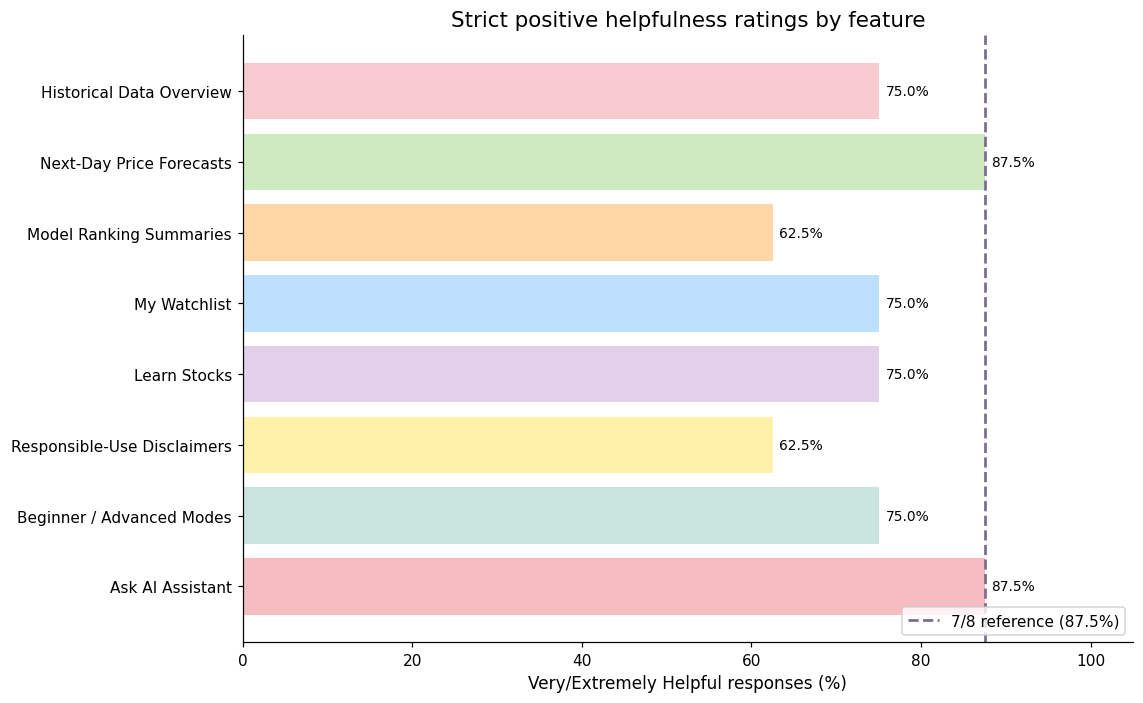

In [72]:
labels = [x[0] for x in feature_summary]
vals = [x[1]['positive_pct'] for x in feature_summary]
fig, ax = plt.subplots(figsize=(10.5, 6.5))
y=np.arange(len(labels))
ax.barh(y, vals, color=PASTEL[1:1+len(labels)])
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.axvline(PASS_PCT, color=ACCENT, linestyle='--', linewidth=1.8, label=f'7/8 reference ({PASS_PCT:.1f}%)')
ax.set_xlim(0,105)
ax.set_xlabel('Very/Extremely Helpful responses (%)')
ax.set_title('Strict positive helpfulness ratings by feature')
ax.legend(loc='lower right')
add_bar_labels(ax, vals, suffix='%')
plt.tight_layout()
plt.show()

In [73]:
display(Markdown(
    "**Feature summary.** All eight evaluated features obtained mean helpfulness scores above 4.0/5, indicating generally favorable evaluations. "
    "Using the stricter 4–5 positive-response count, **Next-Day Price Forecasts** and **Ask AI** each reached 7/8 positive responses (87.5%). "
    "Other features remained positively rated on average but included more 'Moderately Helpful' responses. "
    "The Responsible-Use Disclaimers received the widest spread, including one 'Slightly Helpful' response; however, all 8 respondents separately confirmed that they understood the dashboard's educational/non-advisory purpose."
))

**Feature summary.** All eight evaluated features obtained mean helpfulness scores above 4.0/5, indicating generally favorable evaluations. Using the stricter 4–5 positive-response count, **Next-Day Price Forecasts** and **Ask AI** each reached 7/8 positive responses (87.5%). Other features remained positively rated on average but included more 'Moderately Helpful' responses. The Responsible-Use Disclaimers received the widest spread, including one 'Slightly Helpful' response; however, all 8 respondents separately confirmed that they understood the dashboard's educational/non-advisory purpose.

## 6. Non-functional experience and overall acceptance

The following agreement items capture perceived organization, speed, usefulness, recommendation intent, source/freshness visibility, controls, responsive readability, and visual comfort.

**Important:** perceived speed and responsive readability are stakeholder evidence, but they do **not replace** the separate technical acceptance criteria for measured page-load performance (NFR-03) or viewport/browser testing (NFR-04).

In [74]:
agreement_items = [
    ('Clean / organized; avoids overload', 'clean_organized'),
    ('Loads quickly / transitions smoothly', 'loads_quickly'),
    ('Would use as learning starting point', 'would_use'),
    ('Would recommend to another beginner', 'would_recommend'),
    ('Source / freshness easy to identify', 'source_freshness'),
    ('Controls easy and update as expected', 'controls_work'),
    ('Readable on device; no overflow', 'responsive_readability'),
    ('Colors / theme / text / charts comfortable', 'visual_comfort'),
]
agreement_summary=[]
for label,key in agreement_items:
    s=summarize(key, AGREE)
    agreement_summary.append((label,s))

md_table(
    ['Agreement item', 'Mean / 5', 'Median', 'Agree/Strongly Agree', 'Positive %'],
    [[label, f"{s['mean']:.2f}", f"{s['median']:.1f}", f"{s['positive_n']}/{N}", f"{s['positive_pct']:.1f}%"]
     for label,s in agreement_summary]
)

| Agreement item | Mean / 5 | Median | Agree/Strongly Agree | Positive % |
| --- | --- | --- | --- | --- |
| Clean / organized; avoids overload | 4.38 | 5.0 | 6/8 | 75.0% |
| Loads quickly / transitions smoothly | 4.38 | 5.0 | 6/8 | 75.0% |
| Would use as learning starting point | 4.38 | 4.5 | 7/8 | 87.5% |
| Would recommend to another beginner | 4.38 | 4.5 | 7/8 | 87.5% |
| Source / freshness easy to identify | 4.50 | 5.0 | 7/8 | 87.5% |
| Controls easy and update as expected | 4.50 | 5.0 | 7/8 | 87.5% |
| Readable on device; no overflow | 4.25 | 4.5 | 6/8 | 75.0% |
| Colors / theme / text / charts comfortable | 4.25 | 4.0 | 7/8 | 87.5% |

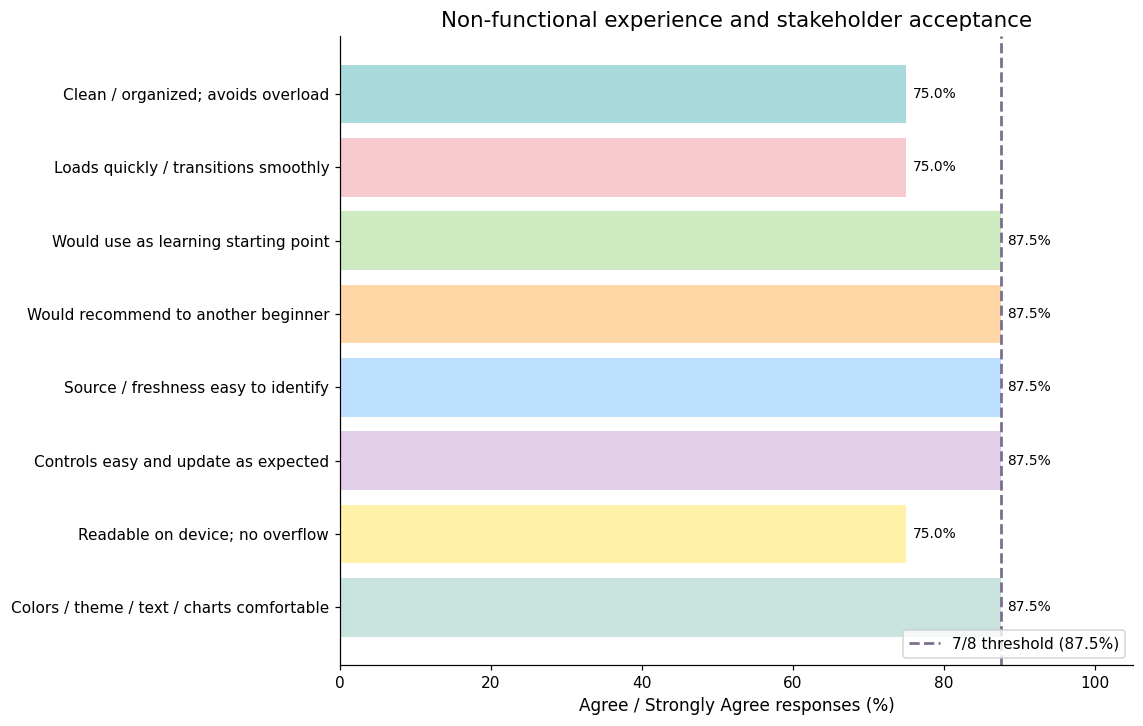

In [75]:
labels=[x[0] for x in agreement_summary]
vals=[x[1]['positive_pct'] for x in agreement_summary]
fig, ax=plt.subplots(figsize=(10.5,6.7))
y=np.arange(len(labels))
ax.barh(y, vals, color=PASTEL[:len(labels)])
ax.set_yticks(y, labels)
ax.invert_yaxis()
ax.axvline(PASS_PCT, color=ACCENT, linestyle='--', linewidth=1.8, label=f'7/8 threshold ({PASS_PCT:.1f}%)')
ax.set_xlim(0,105)
ax.set_xlabel('Agree / Strongly Agree responses (%)')
ax.set_title('Non-functional experience and stakeholder acceptance')
ax.legend(loc='lower right')
add_bar_labels(ax, vals, suffix='%')
plt.tight_layout()
plt.show()

In [76]:
use_s = summarize('would_use', AGREE)
rec_s = summarize('would_recommend', AGREE)
vis_s = summarize('visual_comfort', AGREE)
load_s = summarize('loads_quickly', AGREE)
resp_s = summarize('responsive_readability', AGREE)
clean_s = summarize('clean_organized', AGREE)
source_s = summarize('source_freshness', AGREE)
controls_s = summarize('controls_work', AGREE)

parts = [
    f"**Overall acceptance:** {use_s['positive_n']}/{N} ({use_s['positive_pct']:.1f}%) would use PSE Pulse as a learning starting point, and {rec_s['positive_n']}/{N} ({rec_s['positive_pct']:.1f}%) would recommend it to another beginner. Both meet the 7-of-8 stakeholder acceptance threshold.",
    f"**Readability/theme:** {vis_s['positive_n']}/{N} ({vis_s['positive_pct']:.1f}%) positively rated visual comfort, meeting the stakeholder threshold.",
    f"**Areas for refinement:** perceived information-overload control, loading smoothness, and responsive readability were each 6/8 (75.0%) positive. These are favorable overall but below the 7/8 UAT reference and should be interpreted alongside the separate technical tests."
]
display(Markdown((chr(10)*2).join(parts)))

**Overall acceptance:** 7/8 (87.5%) would use PSE Pulse as a learning starting point, and 7/8 (87.5%) would recommend it to another beginner. Both meet the 7-of-8 stakeholder acceptance threshold.

**Readability/theme:** 7/8 (87.5%) positively rated visual comfort, meeting the stakeholder threshold.

**Areas for refinement:** perceived information-overload control, loading smoothness, and responsive readability were each 6/8 (75.0%) positive. These are favorable overall but below the 7/8 UAT reference and should be interpreted alongside the separate technical tests.

## 7. Requirement-aligned UAT assessment

In [77]:
# Requirement-oriented UAT evidence. Status wording deliberately distinguishes direct acceptance from supporting evidence.
req_rows = [
    ['FR-02', 'Historical OHLCV readability', 'Historical understanding: 7/8 positive; Historical Overview helpfulness: 6/8', 'UAT-supported',
     'Supports usability of historical information; correctness remains supported by technical/output-integrity tests.'],
    ['FR-03', 'Next-session forecast presentation', 'Next-Day Forecasts: 7/8 Very/Extremely Helpful', 'UAT-supported',
     'Strong stakeholder support for the main forecast output.'],
    ['FR-04', 'Actual-versus-predicted comparison', 'Chart clarity: 7/8 positive', 'UAT-supported',
     'Meets the 7/8 perception threshold for clarity.'],
    ['FR-05', 'Company/sector browsing and peer context', 'Company selection: 7/8 positive; cross-company/model clarity: 7/8', 'Partial UAT support',
     'Sector-peer context was not isolated as its own survey item.'],
    ['FR-06', 'Plain-language educational guidance', 'Ask AI: 7/8 positive; Learn Stocks: 6/8 positive', 'Mixed but positive',
     'Open-ended feedback requests tooltips, simpler jargon, and a first-time guide.'],
    ['FR-07', 'Source/freshness visibility', '7/8 Agree/Strongly Agree', 'UAT-supported',
     'Meets the 7/8 stakeholder threshold.'],
    ['FR-08', 'Uncertainty and responsible use', '8/8 understood educational/non-advisory purpose; disclaimer helpfulness 5/8 strict positive', 'Comprehension supported',
     'Understanding is strong; perceived helpfulness of disclaimer presentation is more mixed.'],
    ['FR-09', 'Navigation/search/filter controls', 'Company selection: 7/8 positive; controls: 7/8 positive', 'UAT-supported',
     'Supports usability of navigation and controls.'],
    ['FR-10', 'Comparative model-performance evidence', 'Performance clarity: 7/8; identify best method: 7/8; principal-vs-Naive: 6/8', 'Mostly supported',
     'Naive benchmark distinction is the clearest remaining interpretation issue.'],
    ['NFR-01', 'Clear, summary-first navigation', 'Ease ratings are favorable, but task completion without assistance was not directly recorded in the form', 'Indirect evidence only',
     'Do not claim the formal task-completion criterion from this questionnaire alone.'],
    ['NFR-02', 'Readable charts, labels, language', 'Visual comfort/readability: 7/8 positive', 'Meets UAT rating threshold',
     'Supports the 80% participant-readability requirement.'],
    ['NFR-03', 'Performance', 'Perceived speed: 6/8 positive', 'Supporting perception only',
     'Formal criterion is 90% of measured loads within 5 seconds; use technical performance results separately.'],
    ['NFR-04', 'Responsive multi-device support', 'Perceived responsive readability: 6/8 positive', 'Supporting perception only',
     'Formal criterion requires viewport/browser testing; mobile feedback deserves attention.'],
    ['NFR-05', 'Anonymous access / minimal data', 'Not directly evaluated by UAT question', 'Use technical/privacy evidence',
     'Should be concluded from implementation/privacy testing, not this form.'],
    ['NFR-06', 'Theme-aware visual comfort', '7/8 Agree/Strongly Agree', 'Meets UAT rating threshold',
     'One open-ended response requested light-mode improvement.'],
    ['Overall UAT', 'Understandable and useful educational platform', 'Would use: 7/8; would recommend: 7/8', 'PASS',
     'Meets the predefined stakeholder acceptance threshold.'],
]
md_table(['Requirement', 'Area', 'UAT evidence', 'Assessment', 'Interpretation'], req_rows)

| Requirement | Area | UAT evidence | Assessment | Interpretation |
| --- | --- | --- | --- | --- |
| FR-02 | Historical OHLCV readability | Historical understanding: 7/8 positive; Historical Overview helpfulness: 6/8 | UAT-supported | Supports usability of historical information; correctness remains supported by technical/output-integrity tests. |
| FR-03 | Next-session forecast presentation | Next-Day Forecasts: 7/8 Very/Extremely Helpful | UAT-supported | Strong stakeholder support for the main forecast output. |
| FR-04 | Actual-versus-predicted comparison | Chart clarity: 7/8 positive | UAT-supported | Meets the 7/8 perception threshold for clarity. |
| FR-05 | Company/sector browsing and peer context | Company selection: 7/8 positive; cross-company/model clarity: 7/8 | Partial UAT support | Sector-peer context was not isolated as its own survey item. |
| FR-06 | Plain-language educational guidance | Ask AI: 7/8 positive; Learn Stocks: 6/8 positive | Mixed but positive | Open-ended feedback requests tooltips, simpler jargon, and a first-time guide. |
| FR-07 | Source/freshness visibility | 7/8 Agree/Strongly Agree | UAT-supported | Meets the 7/8 stakeholder threshold. |
| FR-08 | Uncertainty and responsible use | 8/8 understood educational/non-advisory purpose; disclaimer helpfulness 5/8 strict positive | Comprehension supported | Understanding is strong; perceived helpfulness of disclaimer presentation is more mixed. |
| FR-09 | Navigation/search/filter controls | Company selection: 7/8 positive; controls: 7/8 positive | UAT-supported | Supports usability of navigation and controls. |
| FR-10 | Comparative model-performance evidence | Performance clarity: 7/8; identify best method: 7/8; principal-vs-Naive: 6/8 | Mostly supported | Naive benchmark distinction is the clearest remaining interpretation issue. |
| NFR-01 | Clear, summary-first navigation | Ease ratings are favorable, but task completion without assistance was not directly recorded in the form | Indirect evidence only | Do not claim the formal task-completion criterion from this questionnaire alone. |
| NFR-02 | Readable charts, labels, language | Visual comfort/readability: 7/8 positive | Meets UAT rating threshold | Supports the 80% participant-readability requirement. |
| NFR-03 | Performance | Perceived speed: 6/8 positive | Supporting perception only | Formal criterion is 90% of measured loads within 5 seconds; use technical performance results separately. |
| NFR-04 | Responsive multi-device support | Perceived responsive readability: 6/8 positive | Supporting perception only | Formal criterion requires viewport/browser testing; mobile feedback deserves attention. |
| NFR-05 | Anonymous access / minimal data | Not directly evaluated by UAT question | Use technical/privacy evidence | Should be concluded from implementation/privacy testing, not this form. |
| NFR-06 | Theme-aware visual comfort | 7/8 Agree/Strongly Agree | Meets UAT rating threshold | One open-ended response requested light-mode improvement. |
| Overall UAT | Understandable and useful educational platform | Would use: 7/8; would recommend: 7/8 | PASS | Meets the predefined stakeholder acceptance threshold. |

### Requirement interpretation note

The UAT results should be combined with the already completed automated, build, output-integrity, privacy, and browser/performance evidence. A survey response cannot independently verify data correctness, backend integrity, anonymous access, or a measured five-second load-time requirement.

## 8. Device-focused exploratory view

In [78]:
# Small-group descriptive comparison only; no inferential claims are made.
for r in records:
    r['_load_score'] = AGREE[r['loads_quickly']]
    r['_responsive_score'] = AGREE[r['responsive_readability']]
    r['_visual_score'] = AGREE[r['visual_comfort']]

device_scores = defaultdict(lambda: {'n':0,'load':[],'responsive':[],'visual':[]})
for r in records:
    d=device_scores[r['device']]
    d['n'] += 1
    d['load'].append(r['_load_score'])
    d['responsive'].append(r['_responsive_score'])
    d['visual'].append(r['_visual_score'])

device_rows=[]
for dev,d in device_scores.items():
    device_rows.append([dev,d['n'],f"{mean(d['load']):.2f}",f"{mean(d['responsive']):.2f}",f"{mean(d['visual']):.2f}"])
md_table(['Device','n','Mean speed','Mean responsive readability','Mean visual comfort'],device_rows)

| Device | n | Mean speed | Mean responsive readability | Mean visual comfort |
| --- | --- | --- | --- | --- |
| Desktop Computer | 2 | 4.50 | 4.50 | 4.50 |
| Tablet | 1 | 5.00 | 5.00 | 4.00 |
| Laptop | 1 | 5.00 | 4.00 | 4.00 |
| Mobile Phone | 4 | 4.00 | 4.00 | 4.25 |

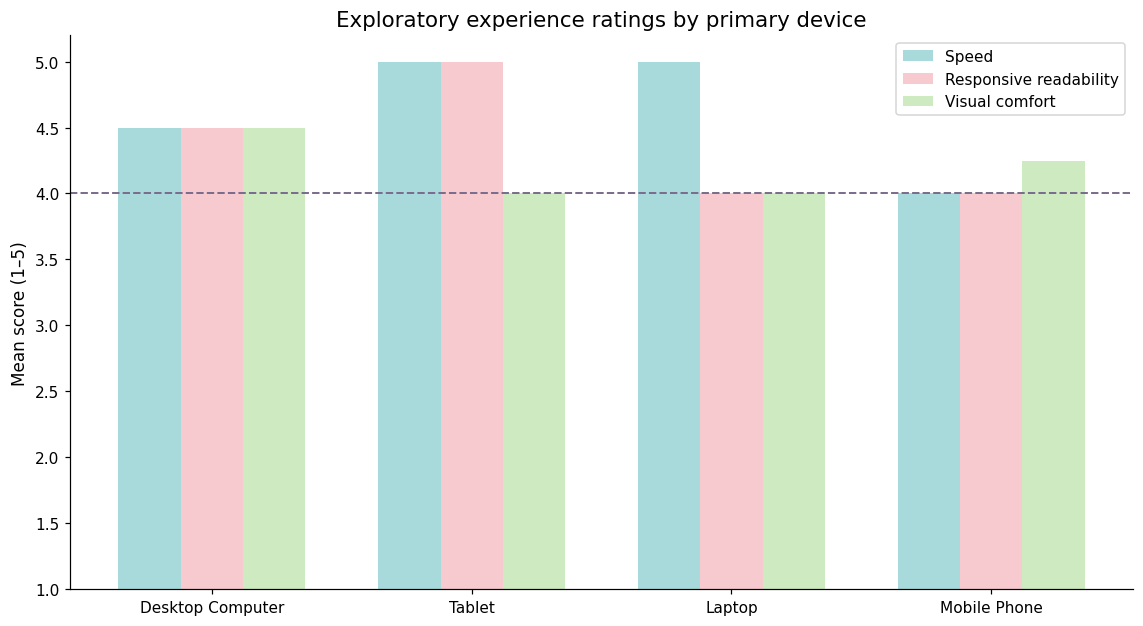

In [79]:
# Grouped bar chart; interpret cautiously because device groups are very small.
devices=list(device_scores.keys())
x=np.arange(len(devices))
width=0.24
load=[mean(device_scores[d]['load']) for d in devices]
resp=[mean(device_scores[d]['responsive']) for d in devices]
visual=[mean(device_scores[d]['visual']) for d in devices]
fig, ax=plt.subplots(figsize=(10.5,5.8))
ax.bar(x-width, load, width, label='Speed', color=PASTEL[0])
ax.bar(x, resp, width, label='Responsive readability', color=PASTEL[1])
ax.bar(x+width, visual, width, label='Visual comfort', color=PASTEL[2])
ax.set_xticks(x, devices)
ax.set_ylim(1,5.2)
ax.set_ylabel('Mean score (1–5)')
ax.set_title('Exploratory experience ratings by primary device')
ax.legend()
ax.axhline(4, color=ACCENT, linestyle='--', linewidth=1.3)
plt.tight_layout()
plt.show()

In [80]:
display(Markdown(
    "**Exploratory device note.** The two neutral ratings for perceived loading speed and responsive readability came from mobile-phone users. "
    "Two other mobile users rated the same items Strongly Agree, so the result is not uniformly negative. "
    "Because the subgroup sizes are very small (mobile n=4; other device groups n=1–2), this pattern should be treated as a practical UI refinement signal rather than a statistical device-effect finding."
))

**Exploratory device note.** The two neutral ratings for perceived loading speed and responsive readability came from mobile-phone users. Two other mobile users rated the same items Strongly Agree, so the result is not uniformly negative. Because the subgroup sizes are very small (mobile n=4; other device groups n=1–2), this pattern should be treated as a practical UI refinement signal rather than a statistical device-effect finding.

## 9. Open-ended feedback and qualitative themes

In [81]:
# Normalize the explicit issue question: blanks/None-type responses mean no concrete defect was reported.
def has_issue(text):
    if text is None:
        return False
    t=str(text).strip().lower()
    return t not in {'', 'none', 'none so far.', 'none so far', 'n/a', 'na'}

issue_count=sum(has_issue(r.get('issues')) for r in records)
no_issue=N-issue_count
md_table(['Open-ended issue reporting','Count','Percent'],[
    ['Concrete confusing/broken/navigation issue reported', issue_count, f'{100*issue_count/N:.1f}%'],
    ['No concrete issue reported', no_issue, f'{100*no_issue/N:.1f}%']
])

| Open-ended issue reporting | Count | Percent |
| --- | --- | --- |
| Concrete confusing/broken/navigation issue reported | 0 | 0.0% |
| No concrete issue reported | 8 | 100.0% |

In [82]:
# Transparent keyword-assisted coding for most-useful-feature comments; themes may overlap.
useful_themes = {
    'Ask AI / explanations': ['ai assistant', 'ask ai', 'ai assistants'],
    'Forecast / next-day / market summary': ['forecast', 'gainer', 'loser'],
    'Historical charts / data': ['chart', 'historical data', 'data overview'],
    'Beginner / Advanced mode': ['beginner and advanced', 'beginner / advanced'],
}
useful_counts=Counter()
for r in records:
    txt=(r.get('most_useful') or '').lower()
    for theme, terms in useful_themes.items():
        if any(term in txt for term in terms):
            useful_counts[theme]+=1

# Recommendation coding; themes may overlap.
rec_themes = {
    'Onboarding / tooltips / simpler terminology': ['tooltip', 'walkthrough', 'guided tour', 'jargon', 'first-time'],
    'Visual / theme refinements': ['light mode', 'color legend'],
    'No additional change requested': ['none', 'already fine', 'all best for me', 'already beginner friendly'],
}
rec_counts=Counter()
for r in records:
    txt=(r.get('recommendations') or '').lower()
    for theme, terms in rec_themes.items():
        if any(term in txt for term in terms):
            rec_counts[theme]+=1

md_table(['Most-useful-feature theme','Mentions'], [[k,v] for k,v in useful_counts.most_common()])
display(Markdown('*Themes may overlap; one response can contribute to more than one theme.*'))

| Most-useful-feature theme | Mentions |
| --- | --- |
| Forecast / next-day / market summary | 4 |
| Ask AI / explanations | 4 |
| Historical charts / data | 3 |
| Beginner / Advanced mode | 1 |

*Themes may overlap; one response can contribute to more than one theme.*

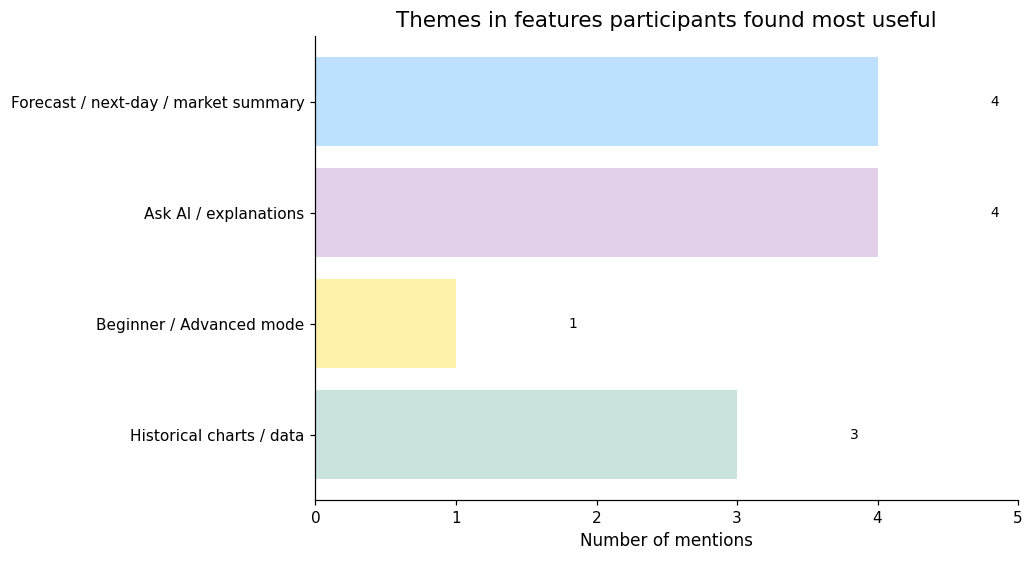

In [83]:
labels=list(useful_counts.keys())
vals=[useful_counts[x] for x in labels]
fig, ax=plt.subplots(figsize=(9.5,5.2))
ax.barh(labels, vals, color=PASTEL[4:4+len(labels)])
ax.invert_yaxis()
ax.set_xlim(0,max(vals)+1)
ax.set_xlabel('Number of mentions')
ax.set_title('Themes in features participants found most useful')
add_bar_labels(ax, vals, fmt='{:.0f}')
plt.tight_layout()
plt.show()

In [84]:
md_table(['Improvement/recommendation theme','Mentions'], [[k,v] for k,v in rec_counts.most_common()])
display(Markdown('*Themes may overlap; recommendations are coded descriptively from the eight open-ended responses.*'))

| Improvement/recommendation theme | Mentions |
| --- | --- |
| Onboarding / tooltips / simpler terminology | 4 |
| No additional change requested | 3 |
| Visual / theme refinements | 2 |

*Themes may overlap; recommendations are coded descriptively from the eight open-ended responses.*

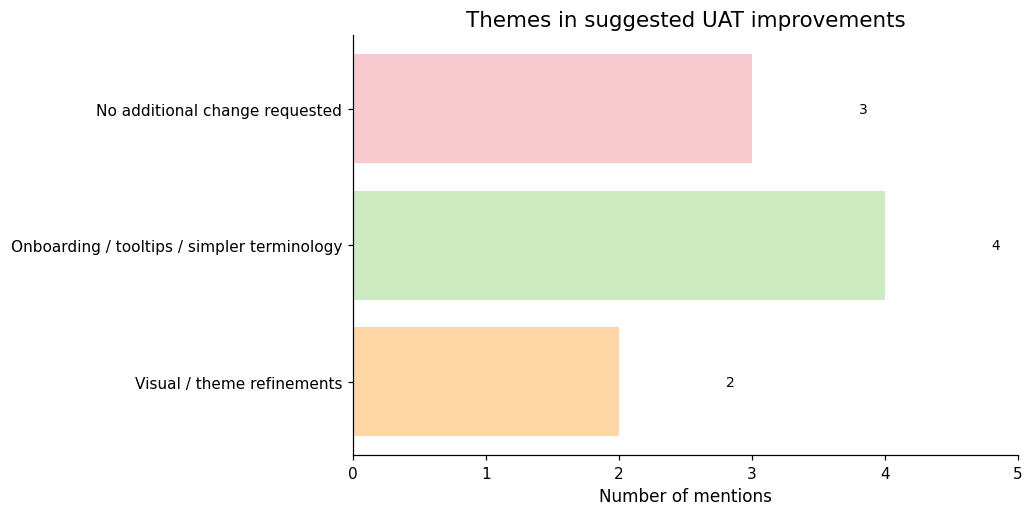

In [85]:
labels=list(rec_counts.keys())
vals=[rec_counts[x] for x in labels]
fig, ax=plt.subplots(figsize=(9.5,4.8))
ax.barh(labels, vals, color=PASTEL[1:1+len(labels)])
ax.invert_yaxis()
ax.set_xlim(0,max(vals)+1)
ax.set_xlabel('Number of mentions')
ax.set_title('Themes in suggested UAT improvements')
add_bar_labels(ax, vals, fmt='{:.0f}')
plt.tight_layout()
plt.show()

In [86]:
display(Markdown(
    "**Qualitative interpretation.** Ask AI was the most frequently mentioned learning aid, followed by forecast/market-summary information and historical charts/data. "
    "The most common improvement theme was **onboarding and explanation support**—including tooltips, a first-time walkthrough/guided tour, and simpler terminology. "
    "Three respondents explicitly indicated that no additional change was necessary or that the current design was already suitable. "
    "No respondent described a concrete broken chart or navigation defect in the dedicated issue question."
))

**Qualitative interpretation.** Ask AI was the most frequently mentioned learning aid, followed by forecast/market-summary information and historical charts/data. The most common improvement theme was **onboarding and explanation support**—including tooltips, a first-time walkthrough/guided tour, and simpler terminology. Three respondents explicitly indicated that no additional change was necessary or that the current design was already suitable. No respondent described a concrete broken chart or navigation defect in the dedicated issue question.

In [87]:
from pathlib import Path
import csv

# Save outputs in the same UAT folder where the notebook is located.
OUTPUT_DIR = Path.cwd()

# If you launch Jupyter from a different folder and this points elsewhere,
# replace Path.cwd() with the exact relative path to your UAT folder.
print("CSV output directory:", OUTPUT_DIR.resolve())

CSV output directory: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat


In [88]:
# ============================================================
# 1. Core UAT usability and interpretation summary
# ============================================================

core_csv = OUTPUT_DIR / "uat_core_usability_summary.csv"

with open(core_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "uat_item",
        "n",
        "mean_score",
        "median_score",
        "positive_count",
        "positive_percent",
        "neutral_count",
        "negative_count",
        "threshold_status"
    ])

    for label, s, status in core_summary:
        writer.writerow([
            label,
            s["n"],
            round(s["mean"], 3),
            round(s["median"], 3),
            s["positive_n"],
            round(s["positive_pct"], 2),
            s["neutral_n"],
            s["negative_n"],
            status
        ])

print(f"Saved: {core_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_core_usability_summary.csv


In [89]:
# ============================================================
# 2. Feature helpfulness summary
# ============================================================

feature_csv = OUTPUT_DIR / "uat_feature_helpfulness_summary.csv"

with open(feature_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "feature",
        "n",
        "mean_helpfulness",
        "median_helpfulness",
        "very_or_extremely_helpful_count",
        "positive_percent",
        "neutral_count",
        "negative_count"
    ])

    for label, s in feature_summary:
        writer.writerow([
            label,
            s["n"],
            round(s["mean"], 3),
            round(s["median"], 3),
            s["positive_n"],
            round(s["positive_pct"], 2),
            s["neutral_n"],
            s["negative_n"]
        ])

print(f"Saved: {feature_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_feature_helpfulness_summary.csv


In [90]:
# ============================================================
# 3. Non-functional experience and acceptance summary
# ============================================================

agreement_csv = OUTPUT_DIR / "uat_acceptance_and_nonfunctional_summary.csv"

with open(agreement_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "agreement_item",
        "n",
        "mean_score",
        "median_score",
        "agree_or_strongly_agree_count",
        "positive_percent",
        "neutral_count",
        "negative_count",
        "meets_7_of_8_threshold"
    ])

    for label, s in agreement_summary:
        writer.writerow([
            label,
            s["n"],
            round(s["mean"], 3),
            round(s["median"], 3),
            s["positive_n"],
            round(s["positive_pct"], 2),
            s["neutral_n"],
            s["negative_n"],
            "Yes" if s["positive_n"] >= PASS_COUNT else "No"
        ])

print(f"Saved: {agreement_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_acceptance_and_nonfunctional_summary.csv


In [91]:
# ============================================================
# 4. Requirement-aligned UAT assessment
# ============================================================

requirements_csv = OUTPUT_DIR / "uat_requirement_alignment.csv"

with open(requirements_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "requirement_id",
        "area",
        "uat_evidence",
        "assessment",
        "interpretation"
    ])

    writer.writerows(req_rows)

print(f"Saved: {requirements_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_requirement_alignment.csv


In [92]:
# ============================================================
# 5. Open-ended qualitative theme summaries
# ============================================================

useful_csv = OUTPUT_DIR / "uat_most_useful_feature_themes.csv"

with open(useful_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["theme", "mentions"])
    for theme, count in useful_counts.most_common():
        writer.writerow([theme, count])

recommendation_csv = OUTPUT_DIR / "uat_improvement_themes.csv"

with open(recommendation_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["theme", "mentions"])
    for theme, count in rec_counts.most_common():
        writer.writerow([theme, count])

print(f"Saved: {useful_csv}")
print(f"Saved: {recommendation_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_most_useful_feature_themes.csv
Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_improvement_themes.csv


In [93]:
# ============================================================
# 6. Consolidated Chapter IV UAT summary
# ============================================================

summary_rows = [
    [
        "Overall use intention",
        use_s["positive_n"],
        N,
        round(use_s["positive_pct"], 2),
        "PASS" if use_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Would recommend to another beginner",
        rec_s["positive_n"],
        N,
        round(rec_s["positive_pct"], 2),
        "PASS" if rec_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Best Principal Model vs Naive understanding",
        principal_s["positive_n"],
        N,
        round(principal_s["positive_pct"], 2),
        "PASS" if principal_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Next-Day Price Forecast helpfulness",
        nextday_s["positive_n"],
        N,
        round(nextday_s["positive_pct"], 2),
        "PASS" if nextday_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Ask AI helpfulness",
        ai_s["positive_n"],
        N,
        round(ai_s["positive_pct"], 2),
        "PASS" if ai_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Visual comfort / readability",
        read_s["positive_n"],
        N,
        round(read_s["positive_pct"], 2),
        "PASS" if read_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Source / freshness visibility",
        source_s["positive_n"],
        N,
        round(source_s["positive_pct"], 2),
        "PASS" if source_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Controls work as expected",
        control_s["positive_n"],
        N,
        round(control_s["positive_pct"], 2),
        "PASS" if control_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Perceived loading speed",
        load_s["positive_n"],
        N,
        round(load_s["positive_pct"], 2),
        "PASS" if load_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
    [
        "Responsive readability",
        resp_s["positive_n"],
        N,
        round(resp_s["positive_pct"], 2),
        "PASS" if resp_s["positive_n"] >= PASS_COUNT else "BELOW THRESHOLD"
    ],
]

summary_csv = OUTPUT_DIR / "uat_chapter4_summary.csv"

with open(summary_csv, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "measure",
        "positive_count",
        "total_participants",
        "positive_percent",
        "threshold_result"
    ])
    writer.writerows(summary_rows)

print(f"Saved: {summary_csv}")

Saved: /Users/arenriquez1/NetBeansProjects/Capstone2-A4103-DigitalDelvers-SY26-27/backend/research-result/uat/uat_chapter4_summary.csv


In [94]:
# ============================================================
# 7. Confirm generated CSV files
# ============================================================

generated_csvs = sorted(OUTPUT_DIR.glob("uat_*.csv"))

print("Generated UAT CSV files:")
for path in generated_csvs:
    print(" -", path.name)

Generated UAT CSV files:
 - uat_acceptance_and_nonfunctional_summary.csv
 - uat_chapter4_summary.csv
 - uat_core_usability_summary.csv
 - uat_feature_helpfulness_summary.csv
 - uat_improvement_themes.csv
 - uat_most_useful_feature_themes.csv
 - uat_requirement_alignment.csv


## 10. Key UAT findings for Chapter IV

In [95]:
principal_s = summarize('principal_vs_naive', EASE)
nextday_s = summarize('forecast_help', HELP)
ai_s = summarize('ask_ai_help', HELP)
read_s = summarize('visual_comfort', AGREE)
source_s = summarize('source_freshness', AGREE)
control_s = summarize('controls_work', AGREE)

summary_text = f"""
### UAT result summary

1. **Overall stakeholder acceptance met the predefined threshold.**  
   - **{use_s['positive_n']}/{N} ({use_s['positive_pct']:.1f}%)** agreed or strongly agreed that they would use PSE Pulse as a starting point for learning about short-term stock behavior.  
   - **{rec_s['positive_n']}/{N} ({rec_s['positive_pct']:.1f}%)** agreed or strongly agreed that they would recommend the educational dashboard to another beginner.

2. **Core navigation and interpretation were generally strong.** Five of six core ease/clarity items reached **7/8 positive responses**. The exception was understanding the **Best Principal Model versus the Naive benchmark**, which reached **{principal_s['positive_n']}/{N} ({principal_s['positive_pct']:.1f}%)**.

3. **The two strongest strict-positive feature evaluations were Next-Day Price Forecasts and Ask AI.** Both received **7/8 (87.5%)** Very/Extremely Helpful ratings.

4. **Readability and theme comfort met the stakeholder threshold.** **{read_s['positive_n']}/{N} ({read_s['positive_pct']:.1f}%)** rated the visual presentation positively.

5. **Source/freshness visibility and control behavior were both positively evaluated by {source_s['positive_n']}/{N} ({source_s['positive_pct']:.1f}%).** This provides stakeholder support for FR-07 and FR-09.

6. **Perceived information-overload control, speed, and responsive readability were each 6/8 (75.0%) positive.** These are favorable but below the 7/8 UAT reference. Speed and responsive layout must still be interpreted using the separate technical performance and browser/viewport evidence because the UAT ratings are subjective perceptions.

7. **Responsible-use comprehension was complete:** all 8 respondents confirmed that they understood that PSE Pulse is educational/analytical and does not provide financial advice or direct trading recommendations.

8. **Open-ended feedback points to refinement rather than major redesign.** The clearest recurring suggestions were tooltips, simpler terminology, a guided first-time walkthrough, and small visual/theme improvements. No concrete broken-chart or navigation defect was reported.
"""
display(Markdown(summary_text))


### UAT result summary

1. **Overall stakeholder acceptance met the predefined threshold.**  
   - **7/8 (87.5%)** agreed or strongly agreed that they would use PSE Pulse as a starting point for learning about short-term stock behavior.  
   - **7/8 (87.5%)** agreed or strongly agreed that they would recommend the educational dashboard to another beginner.

2. **Core navigation and interpretation were generally strong.** Five of six core ease/clarity items reached **7/8 positive responses**. The exception was understanding the **Best Principal Model versus the Naive benchmark**, which reached **6/8 (75.0%)**.

3. **The two strongest strict-positive feature evaluations were Next-Day Price Forecasts and Ask AI.** Both received **7/8 (87.5%)** Very/Extremely Helpful ratings.

4. **Readability and theme comfort met the stakeholder threshold.** **7/8 (87.5%)** rated the visual presentation positively.

5. **Source/freshness visibility and control behavior were both positively evaluated by 7/8 (87.5%).** This provides stakeholder support for FR-07 and FR-09.

6. **Perceived information-overload control, speed, and responsive readability were each 6/8 (75.0%) positive.** These are favorable but below the 7/8 UAT reference. Speed and responsive layout must still be interpreted using the separate technical performance and browser/viewport evidence because the UAT ratings are subjective perceptions.

7. **Responsible-use comprehension was complete:** all 8 respondents confirmed that they understood that PSE Pulse is educational/analytical and does not provide financial advice or direct trading recommendations.

8. **Open-ended feedback points to refinement rather than major redesign.** The clearest recurring suggestions were tooltips, simpler terminology, a guided first-time walkthrough, and small visual/theme improvements. No concrete broken-chart or navigation defect was reported.


## 11. Interpretation limits

- The UAT sample contains only **eight purposively selected participants** and is not statistically representative of all traders or investors.
- The same participants contributed to requirements elicitation and UAT, so the findings demonstrate continuity and acceptance within the intended stakeholder group rather than independent external validation.
- The questionnaire measures **perceived usability, clarity, helpfulness, and acceptance**. It does not establish forecasting accuracy, profitability, or whether users make better investment decisions.
- NFR-03 performance and NFR-04 device compatibility require separate technical measurements; survey perceptions are supporting evidence only.
- The open-ended theme counts are descriptive and allow overlap between themes.

## 12. Suggested Chapter IV interpretation

A defensible interpretation is that **PSE Pulse achieved positive stakeholder acceptance as an educational and analytical interface**, particularly for next-day forecast access, contextual explanations, source/freshness visibility, and general model-comparison usability. The UAT also identifies specific refinement areas: clearer explanation of the principal-model-versus-Naive distinction, simpler terminology/tooltips, guided onboarding, and continued mobile/responsive optimization.

These findings should be reported alongside—not in place of—the completed backend, frontend build, performance, compatibility, privacy, and output-integrity tests.